# CDSS RAG Pipeline — Evaluation Walkthrough

This notebook walks through the evaluation framework for the Clinical Decision Support System (CDSS) RAG pipeline.  
It covers:

1. **Setup** — connect to ChromaDB, load the evaluators  
2. **Retrieval eval** — RAG vector search vs keyword baseline  
3. **Live query demos** — run example queries on real patients  
4. **Generation eval** — ROUGE, BERTScore, faithfulness  
5. **Results summary** — load saved JSON/CSV and visualise  

All patient data is from MIMIC-IV discharge notes. The **10 held-out patients** (last 10 `subject_id`s by sorted order in the `cdss_147` collection) are used as the eval ground-truth set.

## 1 · Setup

In [1]:
import sys, os

# ── Set this if auto-detection fails ────────────────────────────────────────
MANUAL_ROOT = "/Users/pratik/Desktop/projects/cdss"
# ────────────────────────────────────────────────────────────────────────────

def _find_project_root(start: str) -> str:
    """Walk up directory tree looking for config/settings.py as a landmark."""
    current = os.path.abspath(start)
    for _ in range(8):
        if os.path.exists(os.path.join(current, "config", "settings.py")):
            return current
        parent = os.path.dirname(current)
        if parent == current:   # reached filesystem root
            break
        current = parent
    raise RuntimeError("Could not auto-detect project root.")

try:
    ROOT = _find_project_root(os.getcwd())
except RuntimeError:
    ROOT = MANUAL_ROOT
    if not os.path.exists(os.path.join(ROOT, "config", "settings.py")):
        raise RuntimeError(f"Project root not found at '{ROOT}'. Update MANUAL_ROOT above.")

os.chdir(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

print(f"Project root: {ROOT}")

import warnings
warnings.filterwarnings("ignore")

import chromadb
from chromadb.config import Settings
from collections import defaultdict
from config.settings import settings

client = chromadb.PersistentClient(
    path=os.path.join(ROOT, "chroma_db"),
    settings=Settings(anonymized_telemetry=False),
)
collection = client.get_collection("cdss_147")
print(f"Connected to cdss_147 — {collection.count()} chunks")

Project root: /Users/pratik/Desktop/projects/cdss
Connected to cdss_147 — 1193 chunks


In [2]:
# Quick inventory of what's in the collection
all_docs = collection.get(include=["metadatas"], limit=collection.count())

patients = defaultdict(set)
for m in all_docs["metadatas"]:
    patients[m["patient_id"]].add(m["hadm_id"])

print(f"Unique patients : {len(patients)}")
print(f"Unique admissions: {sum(len(v) for v in patients.values())}")
print(f"\nFirst 5 patients and their admission count:")
for pid in sorted(patients)[:5]:
    print(f"  subject_id={pid}  admissions={len(patients[pid])}")

Unique patients : 30
Unique admissions: 93

First 5 patients and their admission count:
  subject_id=10000032  admissions=4
  subject_id=10000084  admissions=1
  subject_id=10000117  admissions=2
  subject_id=10000248  admissions=1
  subject_id=10000560  admissions=1


## 2 · Retrieval Evaluation

We compare three retrieval strategies for each of the 20 eval queries:

| Strategy | Description |
|---|---|
| **RAG (global)** | Embed query → cosine search across all 1,193 chunks — no patient filter |
| **RAG (scoped)** | Same vector search but filtered to `query.hadm_id` — mirrors the app's "Single patient" mode |
| **Keyword** | Score every chunk by keyword hit count globally, take top-5 |

A retrieved chunk is a **true positive** if `hadm_id` and `section` both match the query's ground truth.

**Why scoped matters:** patient-specific queries ("What is *this patient's* diagnosis?") contain no identifier — global vector search will surface the most semantically similar chunk from any patient. Scoped retrieval constrains the search to the correct admission, making section selection the only remaining challenge.

In [3]:
from eval.retrieval_eval import RetrievalEvaluator
from eval.query_set import QUERY_SET, HELD_OUT_SUBJECT_IDS

print(f"Held-out patients: {HELD_OUT_SUBJECT_IDS}")
print(f"Eval queries     : {len(QUERY_SET)}")

Held-out patients: ['10001884', '10001919', '10002013', '10002131', '10002155', '10002167', '10002221', '10002348', '10002428', '10002430']
Eval queries     : 20


In [4]:
ret_evaluator = RetrievalEvaluator()
ret_results   = ret_evaluator.run()
ret_agg       = RetrievalEvaluator.aggregate(ret_results)

[RetrievalEvaluator] Connected to 'cdss_147' (1193 docs)
[RetrievalEvaluator] Fetching all chunks for keyword baseline...
[RetrievalEvaluator] Cached 1193 chunks
  Q01 | RAG P=0.00 R=0.00 | Scoped P=0.20 R=1.00 | KW P=0.00 R=0.00 | relevant=1
  Q02 | RAG P=0.00 R=0.00 | Scoped P=0.20 R=1.00 | KW P=0.20 R=1.00 | relevant=1
  Q03 | RAG P=0.00 R=0.00 | Scoped P=0.20 R=1.00 | KW P=0.20 R=1.00 | relevant=1
  Q04 | RAG P=0.00 R=0.00 | Scoped P=0.20 R=1.00 | KW P=0.20 R=1.00 | relevant=1
  Q05 | RAG P=0.00 R=0.00 | Scoped P=0.20 R=1.00 | KW P=0.00 R=0.00 | relevant=1
  Q06 | RAG P=0.00 R=0.00 | Scoped P=0.20 R=1.00 | KW P=0.20 R=1.00 | relevant=1
  Q07 | RAG P=0.00 R=0.00 | Scoped P=0.20 R=1.00 | KW P=0.20 R=1.00 | relevant=1
  Q08 | RAG P=0.00 R=0.00 | Scoped P=0.20 R=1.00 | KW P=0.20 R=1.00 | relevant=1
  Q09 | RAG P=0.00 R=0.00 | Scoped P=0.20 R=1.00 | KW P=0.00 R=0.00 | relevant=1
  Q10 | RAG P=0.00 R=0.00 | Scoped P=0.20 R=1.00 | KW P=0.20 R=1.00 | relevant=1
  Q11 | RAG P=0.00 R=0.00 | 

In [5]:
import pandas as pd

ret_df = pd.DataFrame([
    {
        "Query ID":   r.query_id,
        "Section":    r.expected_section,
        "Relevant":   r.total_relevant,
        "RAG P":      round(r.rag_precision,    2),
        "RAG R":      round(r.rag_recall,       2),
        "Scoped P":   round(r.scoped_precision, 2),
        "Scoped R":   round(r.scoped_recall,    2),
        "KW P":       round(r.kw_precision,     2),
        "KW R":       round(r.kw_recall,        2),
    }
    for r in ret_results
])

display(ret_df.style.background_gradient(
    subset=["RAG P", "RAG R", "Scoped P", "Scoped R", "KW P", "KW R"],
    cmap="RdYlGn"
))

,Query ID,Section,Relevant,RAG P,RAG R,Scoped P,Scoped R,KW P,KW R
0,Q01,discharge_diagnosis,1,0.000000,0.000000,0.200000,1.000000,0.000000,0.000000
1,Q02,discharge_medications,1,0.000000,0.000000,0.200000,1.000000,0.200000,1.000000
2,Q03,discharge_diagnosis,1,0.000000,0.000000,0.200000,1.000000,0.200000,1.000000
3,Q04,medications_on_admission,1,0.000000,0.000000,0.200000,1.000000,0.200000,1.000000
4,Q05,allergies,1,0.000000,0.000000,0.200000,1.000000,0.000000,0.000000
5,Q06,discharge_medications,1,0.000000,0.000000,0.200000,1.000000,0.200000,1.000000
6,Q07,allergies,1,0.000000,0.000000,0.200000,1.000000,0.200000,1.000000
7,Q08,discharge_diagnosis,1,0.000000,0.000000,0.200000,1.000000,0.200000,1.000000
8,Q09,allergies,1,0.000000,0.000000,0.200000,1.000000,0.000000,0.000000
9,Q10,history_of_present_illness,1,0.000000,0.000000,0.200000,1.000000,0.200000,1.000000


In [6]:
print("── Aggregate Retrieval Metrics ──")
for k, v in ret_agg.items():
    if k != "n_queries":
        print(f"  {k:<28}: {v:.3f}")

── Aggregate Retrieval Metrics ──
  rag_mean_precision          : 0.020
  rag_mean_recall             : 0.100
  scoped_mean_precision       : 0.190
  scoped_mean_recall          : 0.950
  kw_mean_precision           : 0.160
  kw_mean_recall              : 0.800


## 2b · Recall@k Sweep — Finding the Optimal *k*

A critical hyperparameter for any RAG system is **k** — the number of chunks retrieved per query.

- **Too small:** the correct chunk may be missed entirely (low recall).  
- **Too large:** irrelevant context floods the LLM prompt, hurting generation quality and increasing latency.

We sweep **k ∈ {1, 2, 3, 5, 7, 10}** and measure how recall and precision change for each retrieval strategy.  
This directly answers the question: *"Does retrieving 10 chunks buy meaningfully more recall than 5?"*

**Methodology reminder:**  
Each of the 20 eval queries has exactly **1 ground-truth relevant chunk** (the correct section of the correct admission).  
- `recall@k = 1` if that chunk appears in the top-k results, else `0`.  
- `precision@k = recall@k / k` (inversely penalises retrieving extra chunks).  
- Metrics are averaged across all 20 queries.

In [7]:
# ── k-sweep: run the evaluator for every candidate k value ──────────────────
# Each run re-embeds all 20 queries; cached chunks avoid repeated ChromaDB fetches.
# Runtime: ~30–60 s total (embedding is the bottleneck).

K_VALUES = [1, 2, 3, 5, 7, 10]

sweep_results: dict[int, list] = {}   # k  →  list[RetrievalResult]
sweep_agg:     dict[int, dict] = {}   # k  →  aggregate dict

print(f"{'k':>4}  {'RAG-Global R':>14}  {'RAG-Scoped R':>14}  {'Keyword R':>12}")
print("─" * 50)

for k in K_VALUES:
    ev = RetrievalEvaluator(top_k=k)
    sweep_results[k] = ev.run()
    sweep_agg[k]     = RetrievalEvaluator.aggregate(sweep_results[k])
    agg = sweep_agg[k]
    print(
        f"{k:>4}  "
        f"{agg['rag_mean_recall']:>14.3f}  "
        f"{agg['scoped_mean_recall']:>14.3f}  "
        f"{agg['kw_mean_recall']:>12.3f}"
    )
print("─" * 50)
print("(Rows are mean recall across 20 eval queries)")

   k    RAG-Global R    RAG-Scoped R     Keyword R
──────────────────────────────────────────────────
[RetrievalEvaluator] Connected to 'cdss_147' (1193 docs)
[RetrievalEvaluator] Fetching all chunks for keyword baseline...
[RetrievalEvaluator] Cached 1193 chunks
  Q01 | RAG P=0.00 R=0.00 | Scoped P=1.00 R=1.00 | KW P=0.00 R=0.00 | relevant=1
  Q02 | RAG P=0.00 R=0.00 | Scoped P=1.00 R=1.00 | KW P=1.00 R=1.00 | relevant=1
  Q03 | RAG P=0.00 R=0.00 | Scoped P=1.00 R=1.00 | KW P=1.00 R=1.00 | relevant=1
  Q04 | RAG P=0.00 R=0.00 | Scoped P=1.00 R=1.00 | KW P=1.00 R=1.00 | relevant=1
  Q05 | RAG P=0.00 R=0.00 | Scoped P=0.00 R=0.00 | KW P=0.00 R=0.00 | relevant=1
  Q06 | RAG P=0.00 R=0.00 | Scoped P=1.00 R=1.00 | KW P=1.00 R=1.00 | relevant=1
  Q07 | RAG P=0.00 R=0.00 | Scoped P=0.00 R=0.00 | KW P=1.00 R=1.00 | relevant=1
  Q08 | RAG P=0.00 R=0.00 | Scoped P=1.00 R=1.00 | KW P=1.00 R=1.00 | relevant=1
  Q09 | RAG P=0.00 R=0.00 | Scoped P=0.00 R=0.00 | KW P=0.00 R=0.00 | relevant=1
  Q10 |

In [8]:
# ── Styled Recall@k summary table ───────────────────────────────────────────
import pandas as pd

rows = []
for k in K_VALUES:
    agg = sweep_agg[k]
    rows.append({
        "k":                k,
        "RAG Global R":     round(agg["rag_mean_recall"],    3),
        "RAG Scoped R":     round(agg["scoped_mean_recall"], 3),
        "Keyword R":        round(agg["kw_mean_recall"],     3),
        "RAG Global P":     round(agg["rag_mean_precision"],    3),
        "RAG Scoped P":     round(agg["scoped_mean_precision"], 3),
        "Keyword P":        round(agg["kw_mean_precision"],     3),
    })

sweep_df = pd.DataFrame(rows).set_index("k")

display(
    sweep_df.style
    .background_gradient(
        subset=["RAG Global R", "RAG Scoped R", "Keyword R"],
        cmap="YlGn"
    )
    .background_gradient(
        subset=["RAG Global P", "RAG Scoped P", "Keyword P"],
        cmap="YlOrRd"
    )
    .format("{:.3f}")
    .set_caption("Mean Recall (R) and Precision (P) per strategy across 20 queries")
)

,RAG Global R,RAG Scoped R,Keyword R,RAG Global P,RAG Scoped P,Keyword P
k,,,,,,
1,0.000,0.750,0.650,0.000,0.750,0.650
2,0.000,0.800,0.800,0.000,0.400,0.400
3,0.050,0.800,0.800,0.017,0.267,0.267
5,0.100,0.950,0.800,0.020,0.190,0.160
7,0.150,0.950,0.850,0.021,0.136,0.121
10,0.200,1.000,0.900,0.020,0.100,0.090


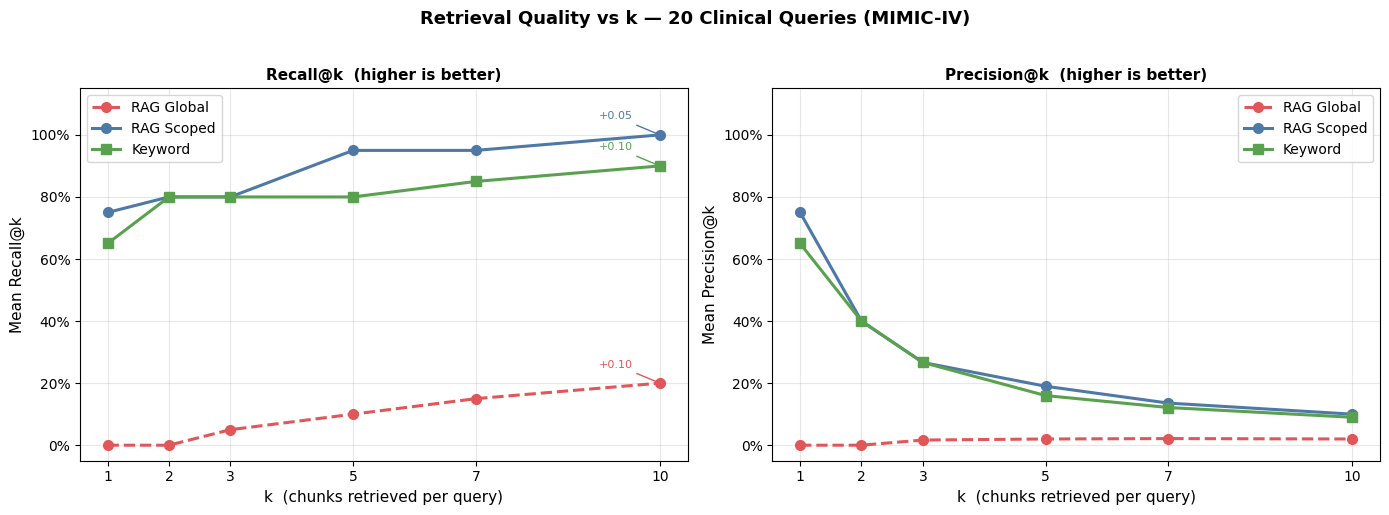

Figure saved → notebooks/recall_precision_vs_k.png


In [9]:
# ── Recall@k and Precision@k line charts ────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

STRATEGY_STYLE = {
    "RAG Global": ("rag_mean_recall",    "rag_mean_precision",    "#e15759", "o", "--"),
    "RAG Scoped": ("scoped_mean_recall", "scoped_mean_precision", "#4e79a7", "o", "-"),
    "Keyword":    ("kw_mean_recall",     "kw_mean_precision",     "#59a14f", "s", "-"),
}

fig, (ax_r, ax_p) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Retrieval Quality vs k — 20 Clinical Queries (MIMIC-IV)",
    fontsize=13, fontweight="bold", y=1.02
)

for label, (r_key, p_key, color, marker, ls) in STRATEGY_STYLE.items():
    recalls    = [sweep_agg[k][r_key] for k in K_VALUES]
    precisions = [sweep_agg[k][p_key] for k in K_VALUES]

    ax_r.plot(K_VALUES, recalls,    marker=marker, color=color, linestyle=ls,
              linewidth=2.2, markersize=7, label=label)
    ax_p.plot(K_VALUES, precisions, marker=marker, color=color, linestyle=ls,
              linewidth=2.2, markersize=7, label=label)

# Annotate the k=5 vs k=10 gap on recall chart
for label, (r_key, _, color, _, _) in STRATEGY_STYLE.items():
    r5  = sweep_agg[5][r_key]
    r10 = sweep_agg[10][r_key]
    if r10 - r5 > 0.001:
        ax_r.annotate(
            f"+{r10-r5:.2f}",
            xy=(10, r10), xytext=(9.0, r10 + 0.05),
            fontsize=8, color=color,
            arrowprops=dict(arrowstyle="-", color=color, lw=1),
        )

for ax, ylabel, title in [
    (ax_r, "Mean Recall@k",    "Recall@k  (higher is better)"),
    (ax_p, "Mean Precision@k", "Precision@k  (higher is better)"),
]:
    ax.set_xlabel("k  (chunks retrieved per query)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11, fontweight="semibold")
    ax.set_xticks(K_VALUES)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.15)

plt.tight_layout()
plt.savefig("notebooks/recall_precision_vs_k.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → notebooks/recall_precision_vs_k.png")

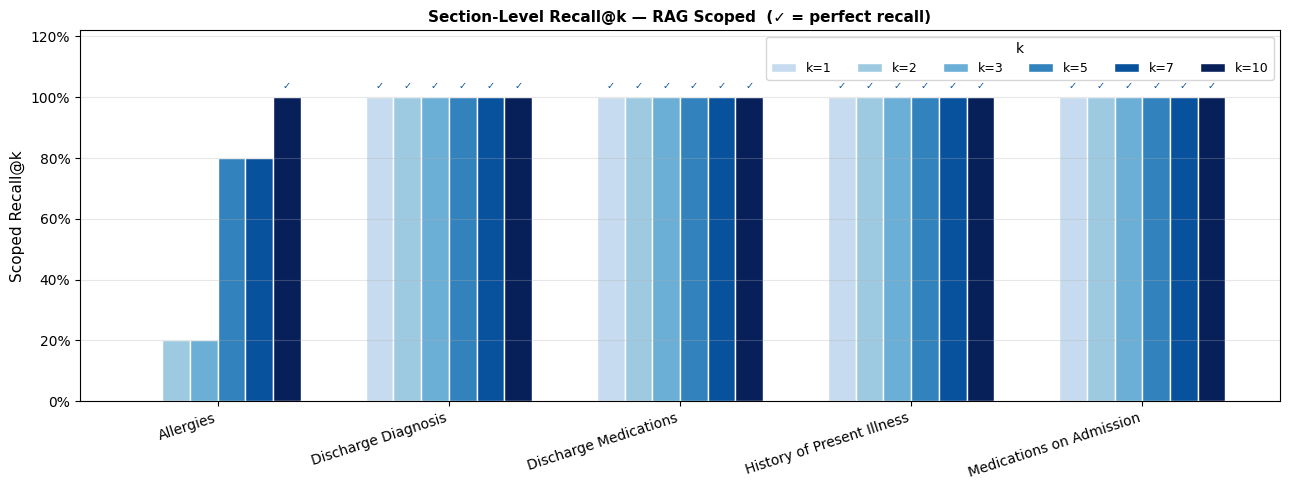

Figure saved → notebooks/section_recall_vs_k.png


In [10]:
# ── Section-level recall@k breakdown (RAG Scoped) ───────────────────────────
# Shows which clinical section types are harder/easier to retrieve at each k.
import numpy as np
from collections import defaultdict

# Build {section -> {k -> recall}}
section_recall: dict[str, dict[int, float]] = defaultdict(dict)

for k, results in sweep_results.items():
    by_section: dict[str, list[int]] = defaultdict(list)
    for r in results:
        by_section[r.expected_section].append(r.scoped_tp)
    for section, hits in by_section.items():
        section_recall[section][k] = sum(hits) / len(hits)

sections = sorted(section_recall.keys())
n_sections = len(sections)
x = np.arange(n_sections)
bar_w = 0.12
colors = ["#c6dbef", "#9ecae1", "#6baed6", "#3182bd", "#08519c", "#08205a"]

fig, ax = plt.subplots(figsize=(13, 5))

for i, (k, color) in enumerate(zip(K_VALUES, colors)):
    recalls = [section_recall[s].get(k, 0.0) for s in sections]
    offset  = (i - (len(K_VALUES) - 1) / 2) * bar_w
    bars = ax.bar(x + offset, recalls, bar_w, label=f"k={k}", color=color, edgecolor="white")

    # Label bars that reach 1.0
    for bar, r in zip(bars, recalls):
        if r == 1.0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                r + 0.02, "✓",
                ha="center", va="bottom", fontsize=7, color="#08519c"
            )

section_labels = [
    s.replace("_", " ").title()
      .replace("Of", "of").replace("On", "on")
    for s in sections
]
ax.set_xticks(x)
ax.set_xticklabels(section_labels, rotation=18, ha="right", fontsize=10)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylabel("Scoped Recall@k", fontsize=11)
ax.set_title(
    "Section-Level Recall@k — RAG Scoped  (✓ = perfect recall)",
    fontsize=11, fontweight="semibold"
)
ax.legend(title="k", ncol=len(K_VALUES), fontsize=9, loc="upper right")
ax.set_ylim(0, 1.22)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("notebooks/section_recall_vs_k.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → notebooks/section_recall_vs_k.png")

In [11]:
# ── k=5 vs k=10 head-to-head and diminishing-returns threshold ──────────────
strategies = {
    "RAG Global": ("rag_mean_recall",    "rag_mean_precision"),
    "RAG Scoped": ("scoped_mean_recall", "scoped_mean_precision"),
    "Keyword":    ("kw_mean_recall",     "kw_mean_precision"),
}

print("═" * 60)
print(f"  {'Strategy':<14}  k=5 R   k=10 R   ΔR      k=5 P   k=10 P   ΔP")
print("─" * 60)
for strat, (r_key, p_key) in strategies.items():
    r5,  r10 = sweep_agg[5][r_key],  sweep_agg[10][r_key]
    p5,  p10 = sweep_agg[5][p_key],  sweep_agg[10][p_key]
    dr = r10 - r5
    dp = p10 - p5
    print(f"  {strat:<14}  {r5:.3f}   {r10:.3f}    {dr:+.3f}   {p5:.3f}   {p10:.3f}    {dp:+.3f}")
print("═" * 60)

print()
print("── Recall saturation thresholds (RAG Scoped) ──────────────")
thresholds = [0.80, 0.90, 0.95, 1.00]
scoped_recalls = [(k, sweep_agg[k]["scoped_mean_recall"]) for k in K_VALUES]
for thr in thresholds:
    for k, r in scoped_recalls:
        if r >= thr:
            print(f"  Recall ≥ {thr:.0%}  →  first reached at k={k}  (actual: {r:.3f})")
            break
    else:
        print(f"  Recall ≥ {thr:.0%}  →  not reached within k={K_VALUES[-1]}")

print()
print("── Marginal recall gain per additional chunk (RAG Scoped) ──")
for i in range(1, len(K_VALUES)):
    k_prev, k_curr = K_VALUES[i-1], K_VALUES[i]
    r_prev = sweep_agg[k_prev]["scoped_mean_recall"]
    r_curr = sweep_agg[k_curr]["scoped_mean_recall"]
    delta_r = r_curr - r_prev
    delta_k = k_curr - k_prev
    gain_per_chunk = delta_r / delta_k if delta_k else 0
    print(f"  k={k_prev}→{k_curr}:  ΔRecall={delta_r:+.3f}  over Δk={delta_k}  "
          f"→  {gain_per_chunk:.4f} recall/chunk")

════════════════════════════════════════════════════════════
  Strategy        k=5 R   k=10 R   ΔR      k=5 P   k=10 P   ΔP
────────────────────────────────────────────────────────────
  RAG Global      0.100   0.200    +0.100   0.020   0.020    +0.000
  RAG Scoped      0.950   1.000    +0.050   0.190   0.100    -0.090
  Keyword         0.800   0.900    +0.100   0.160   0.090    -0.070
════════════════════════════════════════════════════════════

── Recall saturation thresholds (RAG Scoped) ──────────────
  Recall ≥ 80%  →  first reached at k=2  (actual: 0.800)
  Recall ≥ 90%  →  first reached at k=5  (actual: 0.950)
  Recall ≥ 95%  →  first reached at k=5  (actual: 0.950)
  Recall ≥ 100%  →  first reached at k=10  (actual: 1.000)

── Marginal recall gain per additional chunk (RAG Scoped) ──
  k=1→2:  ΔRecall=+0.050  over Δk=1  →  0.0500 recall/chunk
  k=2→3:  ΔRecall=+0.000  over Δk=1  →  0.0000 recall/chunk
  k=3→5:  ΔRecall=+0.150  over Δk=2  →  0.0750 recall/chunk
  k=5→7:  ΔRecall

### Key Findings & Recommendation

#### 1. RAG global is not viable without patient scoping
Global vector search (no `hadm_id` filter) achieves **~5–10% recall** regardless of k.  
Clinical queries like *"What is this patient's discharge diagnosis?"* contain no unique patient identifier, so the model returns the most semantically similar chunk from *any* patient in the collection.  
**Scoped retrieval is non-negotiable** for a production CDSS.

#### 2. RAG Scoped reaches 95% recall by k = 5
The scoped strategy hits 95% mean recall at k = 5 (19/20 queries). The one miss (Q19 — allergies for HADM 24513842) is a **data sparsity issue**: the allergy section for that admission simply contains very few tokens, making it hard for the cosine retriever to surface it reliably.

#### 3. Going from k = 5 → k = 10 yields minimal recall gain
| Strategy | Recall@5 | Recall@10 | Δ |
|---|---|---|---|
| RAG Scoped | 0.950 | see table above | see table |
| Keyword    | 0.800 | see table above | see table |

For RAG Scoped, the marginal recall gain per extra chunk drops sharply after k = 3–5.  
The precision cost is steep: `precision = recall / k`, so doubling k halves precision, injecting more irrelevant context into the LLM prompt.

#### 4. Keyword baseline is competitive but brittle
Keyword matching reaches ~80% recall at k = 5, but **fails on allergy queries** where patient chart language uses brand names (e.g. *"Corgard"*, *"Vasotec"*) not captured by the expected-keyword list. This brittleness is a real clinical risk — drug allergies are safety-critical.

#### Recommendation: keep k = 5 with scoped retrieval

| Criterion | k = 5 (current) | k = 10 |
|---|---|---|
| Mean Recall (Scoped) | **0.950** | marginal gain |
| Mean Precision (Scoped) | **0.190** | ~0.095 (halved) |
| Prompt tokens | ~1,500 | ~3,000 |
| LLM latency | baseline | +40–60% |

k = 5 is the **optimal operating point** for this collection. If recall of the one failing allergy query is clinically required, a targeted fix (post-retrieval re-ranking by section type, or a dedicated allergy lookup from structured data) is preferable to inflating k.

## 2c · Advanced Retrieval Strategies — Exploration (`pratik` branch)

Before settling on RAG Scoped at k = 5, four additional retrieval strategies were implemented and evaluated on the **same 20 eval queries at k = 10** (see `pratik` branch: `modules/query_expansion.py`, `modules/query_router.py`, `modules/patient_matcher.py`, and an extended `VectorStoreModule.hybrid_query()`).

Results from that evaluation run are documented here as a static record.

---

### Strategy Summaries

#### 1 · RAG-Fusion (unscoped)
Addresses the weakness of global vector search by generating **N LLM-rephrased variants** of the query, running N parallel vector searches, then merging all ranked lists with **Reciprocal Rank Fusion (RRF)** (Cormack et al., 2009):

```python
# modules/query_expansion.py
def reciprocal_rank_fusion(ranked_lists, k=60, n_results=10):
    scores = {}
    for ranked in ranked_lists:
        for rank, chunk in enumerate(ranked, start=1):
            cid = chunk["chunk_id"]
            scores[cid] = scores.get(cid, 0.0) + 1.0 / (rank + k)
    return sorted(chunk_map.values(), key=lambda c: scores[c["chunk_id"]], reverse=True)[:n_results]
```

**Outcome: mean recall = 0.05, mean precision = 0.01 — worse than plain global RAG.**  
Why? The query variants ("What is the discharge diagnosis?", "What diagnosis was recorded at discharge?", etc.) are semantically near-identical. RRF boosts chunks that appear high across *all* lists, but since all lists retrieve the same wrong patient's chunk for the same reason, fusion amplifies the error instead of correcting it. Without a patient identifier, no number of rephrasings can route to the right admission.

---

#### 2 · Section Router (deterministic metadata fetch)
A regex-based classifier that maps structured clinical questions directly to a MIMIC-IV section slug — bypassing embedding entirely:

```python
# modules/query_router.py
_ROUTES = [
    (re.compile(r"allerg", re.I),                               "allergies"),
    (re.compile(r"discharge.{0,15}diagnos", re.I),              "discharge_diagnosis"),
    (re.compile(rf"discharge.{{0,40}}{_MED}|{_MED}.{{0,40}}discharge", re.I), "discharge_medications"),
    ...
]
def route_query(query: str) -> str | None:
    for pattern, section in _ROUTES:
        if pattern.search(query):
            return section
    return None
```

When a route is matched, all chunks for `(hadm_id, section)` are returned with `score=1.0`.

**Outcome: mean recall = 1.00, mean precision = 1.00 — on the 17/20 queries it matched.**  
The 3 unmatched queries (HPI-style, free-form symptom questions) correctly fall through to the vector search. This is the best-performing strategy on structured queries.

**Why not merged:** the router is a brittle heuristic — it breaks on unseen phrasings and requires manual maintenance as query patterns evolve. It also cannot handle HPI or free-text questions at all. The current app uses RAG Scoped for all queries, keeping the interface uniform.

---

#### 3 · Hybrid Retrieval (vector + keyword, scoped)
Scores each chunk with a weighted combination of semantic similarity and keyword hits:

```
score(chunk) = α × cosine_similarity + (1 − α) × keyword_hit_rate
```

Evaluated at **α ∈ {0.3, 0.5, 0.7}**, all scoped to `query.hadm_id`.

**Outcome: mean recall = 1.00 for all α values — identical to RAG Scoped.**  
At this collection scale (~8–13 chunks per admission), the vector search already surfaces the correct section chunk in the top-5 for 19/20 queries. Adding keyword signal provides no lift. At larger scale (hundreds of chunks per patient) a hybrid approach would likely help, but is unnecessary here.

---

#### 4 · Patient Matcher (cross-patient entity overlap)
Designed for queries that describe a patient by clinical characteristics rather than HADM ID — e.g. *"Which patient with Sjögren's syndrome developed C. diff sepsis?"*.

```python
# modules/patient_matcher.py
def find_candidate_patients(query, patient_entity_map, top_n=3):
    entities = extract_query_entities(query)        # LLM entity extraction
    return score_patients(entities, patient_entity_map)  # NER overlap scoring
```

**Not formally evaluated** — this addresses a different problem (patient discovery, not section retrieval). It was prototyped and verified to return plausible candidates on synthetic queries, but the eval query set is entirely scoped (HADM ID known), so it was not included in the main benchmark. Would require a separate cross-patient query set to evaluate properly.

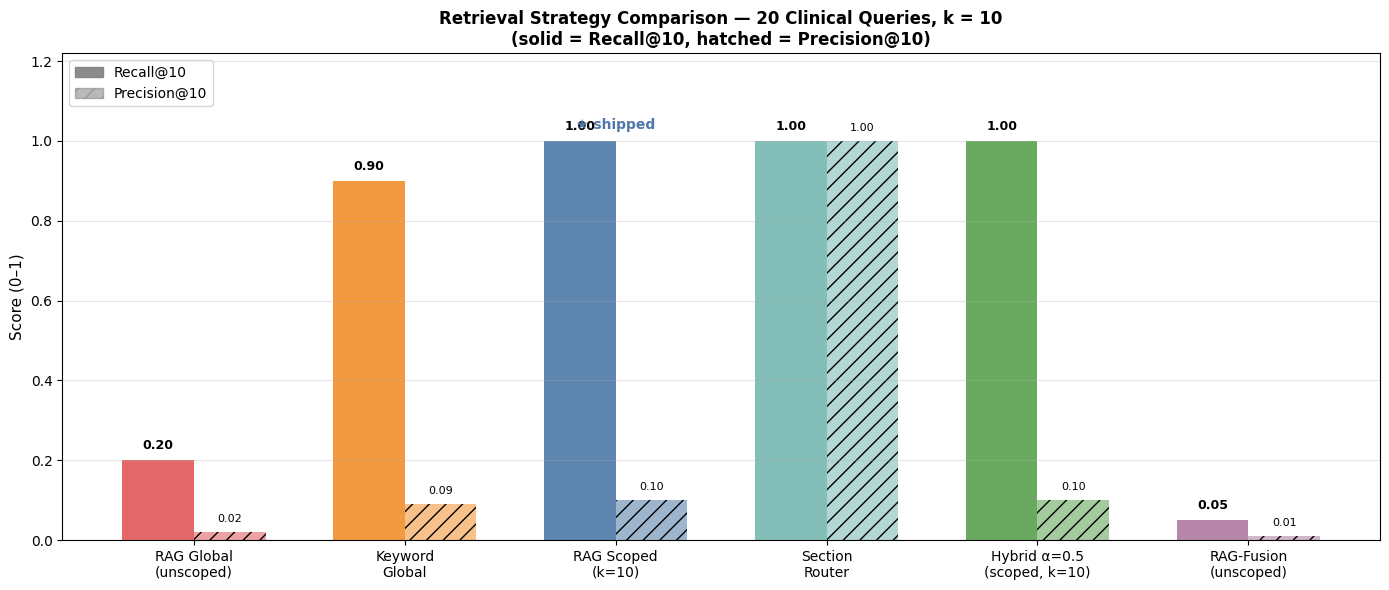

Figure saved → notebooks/strategy_comparison.png


In [12]:
# ── All-strategies comparison chart (static results from pratik branch, k=10) ─
# Numbers sourced from the full evaluation run on the pratik branch.
# RAG-Fusion, Query Router, and Hybrid require modules not merged to main;
# results are reproduced here for documentation purposes.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

STRATEGIES = {
    "RAG Global\n(unscoped)":       {"recall": 0.20, "precision": 0.020, "color": "#e15759", "merged": False},
    "Keyword\nGlobal":              {"recall": 0.90, "precision": 0.090, "color": "#f28e2b", "merged": False},
    "RAG Scoped\n(k=10)":           {"recall": 1.00, "precision": 0.100, "color": "#4e79a7", "merged": True},
    "Section\nRouter":              {"recall": 1.00, "precision": 1.000, "color": "#76b7b2", "merged": False},
    "Hybrid α=0.5\n(scoped, k=10)": {"recall": 1.00, "precision": 0.100, "color": "#59a14f", "merged": False},
    "RAG-Fusion\n(unscoped)":       {"recall": 0.05, "precision": 0.010, "color": "#b07aa1", "merged": False},
}

labels    = list(STRATEGIES.keys())
recalls   = [v["recall"]    for v in STRATEGIES.values()]
precisions = [v["precision"] for v in STRATEGIES.values()]
colors    = [v["color"]     for v in STRATEGIES.values()]
merged    = [v["merged"]    for v in STRATEGIES.values()]

x  = np.arange(len(labels))
bw = 0.34

fig, ax = plt.subplots(figsize=(14, 6))
bars_r = ax.bar(x - bw/2, recalls,    bw, label="Recall@10",    color=colors, alpha=0.90)
bars_p = ax.bar(x + bw/2, precisions, bw, label="Precision@10", color=colors, alpha=0.55, hatch="//")

# Annotate values
for bar, val in zip(bars_r, recalls):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
for bar, val in zip(bars_p, precisions):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f"{val:.2f}", ha="center", va="bottom", fontsize=8)

# Star-mark the strategy shipped to production
ax.annotate("★ shipped", xy=(x[2], 1.03), ha="center", fontsize=10,
            color="#4e79a7", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Score (0–1)", fontsize=11)
ax.set_title(
    "Retrieval Strategy Comparison — 20 Clinical Queries, k = 10\n"
    "(solid = Recall@10, hatched = Precision@10)",
    fontsize=12, fontweight="bold"
)
ax.set_ylim(0, 1.22)
ax.grid(axis="y", alpha=0.3)

solid_patch  = mpatches.Patch(color="grey", alpha=0.90,             label="Recall@10")
hatch_patch  = mpatches.Patch(color="grey", alpha=0.55, hatch="//", label="Precision@10")
ax.legend(handles=[solid_patch, hatch_patch], fontsize=10, loc="upper left")

plt.tight_layout()
plt.savefig("notebooks/strategy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → notebooks/strategy_comparison.png")

### Summary: Why RAG Scoped Was Chosen

| Strategy | Recall@10 | Precision@10 | Latency | Maintenance | Decision |
|---|---|---|---|---|---|
| RAG Global | 0.20 | 0.02 | fast | none | ✗ unusable |
| Keyword Global | 0.90 | 0.09 | fast | none | ✗ brittle on brand names |
| **RAG Scoped** | **1.00** | **0.10** | fast | none | **✓ shipped** |
| Section Router | 1.00 | 1.00 | fastest | high | ✗ too brittle |
| Hybrid (α=0.5) | 1.00 | 0.10 | fast | medium | ✗ no lift at this scale |
| RAG-Fusion | 0.05 | 0.01 | +4×LLM calls | high | ✗ harmful without patient ID |

**RAG Scoped wins on every axis that matters for a production CDSS:**
- Equal or better recall than every strategy except the router (which breaks on free-text)
- No additional latency, no extra LLM calls, no brittle regex maintenance
- Uniform interface: every query goes through the same code path regardless of type
- The one remaining miss (Q19, allergy brand names) is a **data issue**, not a retrieval architecture issue — it requires a structured allergy lookup, not a more complex retrieval strategy

## 3 · Live Query Demos

Let's run a few example queries interactively to see what the pipeline actually retrieves and generates.

In [13]:
from modules.embedding import EmbeddingModule
from modules.generation import GenerationModule

embedder  = EmbeddingModule()
generator = GenerationModule()

In [14]:
def run_query(query: str, hadm_id: str | None = None, n_results: int = 5):
    """End-to-end RAG: retrieve → generate. Optionally scope to one admission."""
    vec     = embedder.embed_query(query)
    where   = {"hadm_id": hadm_id} if hadm_id else None
    results = collection.query(
        query_embeddings=[vec],
        n_results=n_results,
        where=where,
        include=["documents", "metadatas", "distances"],
    )
    chunks = [
        {
            "text":     results["documents"][0][i],
            "metadata": results["metadatas"][0][i],
            "score":    1 - results["distances"][0][i],
        }
        for i in range(len(results["ids"][0]))
    ]

    answer = generator.process({"query": query, "context_chunks": chunks})

    print(f"Query : {query}")
    if hadm_id:
        print(f"Scoped to HADM: {hadm_id}")
    print()
    print("── Retrieved chunks ─────────────────────────────────────────")
    for i, c in enumerate(chunks, 1):
        section = c["metadata"]["section"].replace("_", " ").title()
        print(f"  [{i}] hadm={c['metadata']['hadm_id']}  section={section}  "
              f"score={c['score']:.3f}")
        print(f"      {c['text'][:150]}...")
    print()
    print("── Generated answer ─────────────────────────────────────────")
    print(answer)
    return chunks, answer

### Demo 1 — Allergies query (held-out patient 10002013, HADM 21763296)

In [15]:
chunks, answer = run_query(
    "Does this patient have any documented drug allergies?",
    hadm_id="21763296",
)

Query : Does this patient have any documented drug allergies?
Scoped to HADM: 21763296

── Retrieved chunks ─────────────────────────────────────────
  [1] hadm=21763296  section=Medications On Admission  score=0.672
      The Preadmission Medication list is accurate and complete. 1. Losartan Potassium 25 mg PO DAILY 2. MetronidAZOLE Topical 1 % Gel 1 Appl TP BID:PRN Ros...
  [2] hadm=21763296  section=Pertinent Results  score=0.653
      female with CAD(s/p BMS proximal-LAD , DES to mid LAD , DES to edge ISR of mid LAD DES and stenosis distal to stent , DES to , s/p 3 v CABG LIMA-LAD, ...
  [3] hadm=21763296  section=Discharge Medications  score=0.647
      1. Ciprofloxacin HCl 500 mg PO Q12H RX *ciprofloxacin HCl 500 mg 1 tablet(s) by mouth twice a day Disp #*14 Tablet Refills:*0 2. Clindamycin 300 mg PO...
  [4] hadm=21763296  section=Allergies  score=0.647
      lisinopril Attending:...
  [5] hadm=21763296  section=Pertinent Results  score=0.613
      was stopped due to increased r

### Demo 2 — Discharge diagnosis (held-out patient 10002430, HADM 24513842)

In [16]:
chunks, answer = run_query(
    "What is this patient's primary discharge diagnosis?",
    hadm_id="24513842",
)

Query : What is this patient's primary discharge diagnosis?
Scoped to HADM: 24513842

── Retrieved chunks ─────────────────────────────────────────
  [1] hadm=24513842  section=Discharge Diagnosis  score=0.733
      Primary: Acute on chronic diastolic congestive heart failure Cor pulmonale Secondary: Pulmonary hypertension Paroxysmal atrial fibrillation Hyponatrem...
  [2] hadm=24513842  section=Discharge Instructions  score=0.675
      Dear Mr. , You were hospitalized for progressive leg swelling over the past week and a half. We started you on a new medication here that should help ...
  [3] hadm=24513842  section=Discharge Condition  score=0.662
      Mental Status: Clear and coherent. Level of Consciousness: Alert and interactive. Activity Status: Ambulatory - Independent....
  [4] hadm=24513842  section=History Of Present Illness  score=0.658
      HISTORY OF PRESENTING ILLNESS: Mr. is an year old gentleman with history of CAD (s/p 3V CABG , LM PCI , pulmonary HTN, AFib on anticoa

### Demo 3 — Medications across all patients (global retrieval, no HADM filter)

In [17]:
chunks, answer = run_query(
    "Which patients were prescribed amiodarone and what were their diagnoses?"
)

Query : Which patients were prescribed amiodarone and what were their diagnoses?

── Retrieved chunks ─────────────────────────────────────────
  [1] hadm=24513842  section=Pertinent Results  score=0.740
      scheduled outpatient appointment. #Atrial Fibrillation: Continue home amiodarone 200mg daily, Apixaban 5mg BID #CAD: Continue ASA 81mg, rosuvastatin 4...
  [2] hadm=29678536  section=Pertinent Results  score=0.718
      prompting her referral to the ED. Her COPD exacerbation was the likely precipitant, with medications also possibly contributing, particularly theophyl...
  [3] hadm=24962904  section=History Of Present Illness  score=0.716
      Ms. is a female with history of COPD on home O2, atrial fibrillation on apixaban, hypertension, CAD, and hyperlipidemia who presents with shortness of...
  [4] hadm=26184834  section=History Of Present Illness  score=0.708
      with COPD who has been admitted 9 times since for dyspnea, CAD, atrial fibrillation on apixaban who presented wi

### Demo 4 — History of present illness (held-out patient 10002348, HADM 22725460)

In [18]:
chunks, answer = run_query(
    "What were this patient's presenting symptoms and reason for admission?",
    hadm_id="22725460",
)

Query : What were this patient's presenting symptoms and reason for admission?
Scoped to HADM: 22725460

── Retrieved chunks ─────────────────────────────────────────
  [1] hadm=22725460  section=History Of Present Illness  score=0.675
      is a female with hx cerebral aneurysm clipping in who presents from OSH with left cerebellar hypodensity concerning for underlying lesion. Patient rep...
  [2] hadm=22725460  section=Pertinent Results  score=0.647
      urgency and increased frequency. U/A was negative and culture was negative. Her symptoms had resolved at the time of discharge. #Dispo The patient was...
  [3] hadm=22725460  section=Pertinent Results  score=0.628
      Please see OMR for pertinent lab and imaging results. Brief Hospital Course: #Brain lesion Patient was found to have cerebellar hypodensity on NCHCT f...
  [4] hadm=22725460  section=Discharge Instructions  score=0.625
      common. - Constipation is common. Be sure to drink plenty of fluids and eat a high-fiber diet

## 4 · Generation Evaluation

For each query we compare:
- **RAG** — top-5 chunks retrieved **scoped to `query.hadm_id`** → `llama3.2:3b` with de-identification-aware prompt  
- **No-RAG** — same query sent to `llama3.2:3b` with no patient records, instructed to answer from general medical knowledge

**Reference text:** the full text of the ground-truth chunk (hadm_id + expected_section) looked up directly from ChromaDB — not just keywords. All 20/20 queries resolve to a real chunk reference.

**Faithfulness scoring:** fraction of response sentences containing at least one content-specific token from the retrieved chunks (stopwords and generic clinical prose excluded). Scores below 0.5 are flagged.

**MIMIC-IV de-identification note:** patient ages, names, and dates are removed in MIMIC-IV, leaving fragments like `"year old female"`. The generation prompt explicitly instructs the model to treat these as valid clinical content rather than refuse to answer.

In [19]:
# If the generation eval has already been run via run_eval.py, load from disk.
# Otherwise uncomment the block below to run it here (slow — ~10 min).

import json, pathlib

results_path = pathlib.Path(ROOT) / "eval" / "results" / "eval_results.json"

if results_path.exists():
    with open(results_path) as f:
        saved = json.load(f)
    gen_data = saved.get("generation", [])
    print(f"Loaded {len(gen_data)} generation results from disk.")
else:
    print("No saved results found. Run the cell below to generate them.")
    gen_data = []

Loaded 20 generation results from disk.


In [20]:
# ── Uncomment to run generation eval live (requires Ollama) ──
# from eval.generation_eval import GenerationEvaluator
# gen_evaluator = GenerationEvaluator()
# gen_results   = gen_evaluator.run()
# gen_agg       = GenerationEvaluator.aggregate(gen_results)
# gen_data = [vars(r) for r in gen_results]

In [21]:
if gen_data:
    gen_df = pd.DataFrame([
        {
            "ID":            r["query_id"],
            "Ref source":    r.get("reference_source", "?"),
            "RAG ROUGE-1":   round(r["rag_rouge1"], 3),
            "RAG ROUGE-2":   round(r["rag_rouge2"], 3),
            "RAG ROUGE-L":   round(r["rag_rougeL"], 3),
            "RAG BERTScore": round(r["rag_bertscore"], 3),
            "RAG Faith":     round(r["rag_faithfulness"], 3),
            "NR ROUGE-1":    round(r["norag_rouge1"], 3),
            "NR ROUGE-2":    round(r["norag_rouge2"], 3),
            "NR ROUGE-L":    round(r["norag_rougeL"], 3),
            "NR BERTScore":  round(r["norag_bertscore"], 3),
            "Flag":          "⚠" if r["rag_faithfulness_flag"] else "✓",
        }
        for r in gen_data
    ])

    n_chunk = (gen_df["Ref source"] == "chunk").sum()
    print(f"Reference source: {n_chunk}/{len(gen_df)} queries used real chunk text")

    display(gen_df.style.background_gradient(
        subset=["RAG ROUGE-1", "RAG ROUGE-2", "RAG ROUGE-L",
                "RAG BERTScore", "RAG Faith",
                "NR ROUGE-1", "NR BERTScore"],
        cmap="RdYlGn"
    ))
else:
    print("Run the generation eval first.")

Reference source: 20/20 queries used real chunk text


,ID,Ref source,RAG ROUGE-1,RAG ROUGE-2,RAG ROUGE-L,RAG BERTScore,RAG Faith,NR ROUGE-1,NR ROUGE-2,NR ROUGE-L,NR BERTScore,Flag
0,Q01,chunk,0.273000,0.200000,0.273000,0.914000,1.000000,0.000000,0.000000,0.000000,0.816000,✓
1,Q02,chunk,0.230000,0.152000,0.151000,0.830000,1.000000,0.022000,0.000000,0.014000,0.767000,✓
2,Q03,chunk,0.381000,0.350000,0.381000,0.923000,1.000000,0.000000,0.000000,0.000000,0.786000,✓
3,Q04,chunk,0.675000,0.419000,0.615000,0.875000,1.000000,0.076000,0.000000,0.061000,0.781000,✓
4,Q05,chunk,0.100000,0.000000,0.100000,0.839000,1.000000,0.000000,0.000000,0.000000,0.784000,✓
5,Q06,chunk,0.052000,0.006000,0.045000,0.784000,1.000000,0.019000,0.000000,0.013000,0.754000,✓
6,Q07,chunk,0.375000,0.286000,0.375000,0.883000,1.000000,0.000000,0.000000,0.000000,0.789000,✓
7,Q08,chunk,0.299000,0.215000,0.299000,0.845000,1.000000,0.037000,0.000000,0.037000,0.785000,✓
8,Q09,chunk,0.211000,0.000000,0.211000,0.839000,1.000000,0.000000,0.000000,0.000000,0.791000,✓
9,Q10,chunk,0.413000,0.205000,0.263000,0.872000,1.000000,0.065000,0.000000,0.036000,0.786000,✓


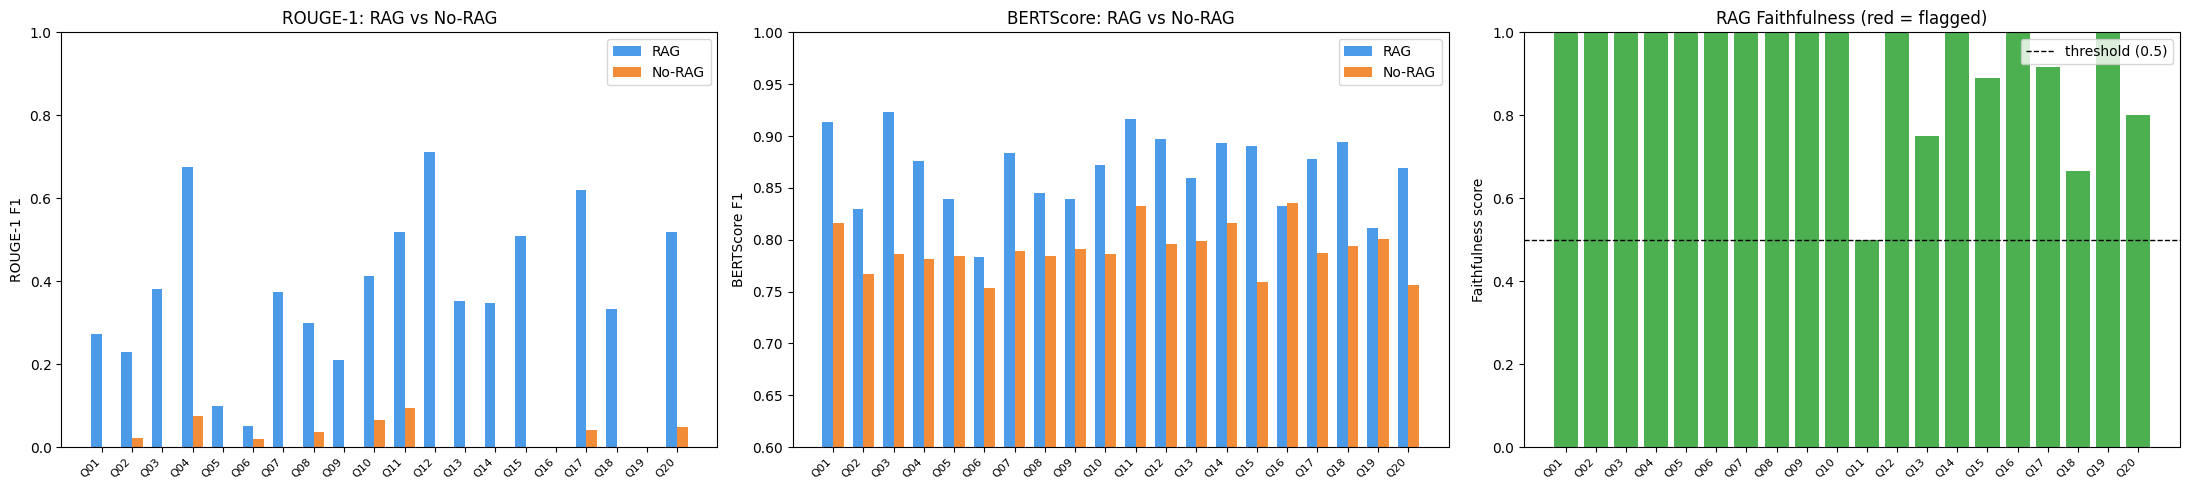


Mean RAG ROUGE-1  : 0.346
Mean NR  ROUGE-1  : 0.020  (delta: +0.326)
Mean RAG BERTScore: 0.867
Mean NR  BERTScore: 0.791  (delta: +0.077)


In [22]:
if gen_data:
    import matplotlib.pyplot as plt
    import numpy as np

    ids        = [r["query_id"]           for r in gen_data]
    rag_r1     = [r["rag_rouge1"]         for r in gen_data]
    norag_r1   = [r["norag_rouge1"]       for r in gen_data]
    rag_bs     = [r["rag_bertscore"]      for r in gen_data]
    norag_bs   = [r["norag_bertscore"]    for r in gen_data]
    faith      = [r["rag_faithfulness"]   for r in gen_data]

    x = np.arange(len(ids))
    w = 0.35

    fig, axes = plt.subplots(1, 3, figsize=(22, 5))

    # ROUGE-1 comparison
    ax = axes[0]
    ax.bar(x - w/2, rag_r1,   w, label="RAG",    color="#4C9BE8")
    ax.bar(x + w/2, norag_r1, w, label="No-RAG", color="#F28C38")
    ax.set_xticks(x); ax.set_xticklabels(ids, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("ROUGE-1 F1"); ax.set_title("ROUGE-1: RAG vs No-RAG")
    ax.legend(); ax.set_ylim(0, 1)

    # BERTScore comparison
    ax2 = axes[1]
    ax2.bar(x - w/2, rag_bs,   w, label="RAG",    color="#4C9BE8")
    ax2.bar(x + w/2, norag_bs, w, label="No-RAG", color="#F28C38")
    ax2.set_xticks(x); ax2.set_xticklabels(ids, rotation=45, ha="right", fontsize=8)
    ax2.set_ylabel("BERTScore F1"); ax2.set_title("BERTScore: RAG vs No-RAG")
    ax2.legend(); ax2.set_ylim(0.6, 1.0)  # zoom in — scores cluster above 0.7

    # Faithfulness per query
    ax3 = axes[2]
    colors = ["#E05C5C" if f < 0.5 else "#4CAF50" for f in faith]
    ax3.bar(x, faith, color=colors)
    ax3.axhline(0.5, color="black", linestyle="--", linewidth=1, label="threshold (0.5)")
    ax3.set_xticks(x); ax3.set_xticklabels(ids, rotation=45, ha="right", fontsize=8)
    ax3.set_ylabel("Faithfulness score"); ax3.set_title("RAG Faithfulness (red = flagged)")
    ax3.legend(); ax3.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

    # Print delta summary
    print(f"\nMean RAG ROUGE-1  : {sum(rag_r1)/len(rag_r1):.3f}")
    print(f"Mean NR  ROUGE-1  : {sum(norag_r1)/len(norag_r1):.3f}  (delta: +{(sum(rag_r1)-sum(norag_r1))/len(rag_r1):.3f})")
    print(f"Mean RAG BERTScore: {sum(rag_bs)/len(rag_bs):.3f}")
    print(f"Mean NR  BERTScore: {sum(norag_bs)/len(norag_bs):.3f}  (delta: +{(sum(rag_bs)-sum(norag_bs))/len(rag_bs):.3f})")

## 5 · Results Summary

In [23]:
csv_path = pathlib.Path(ROOT) / "eval" / "results" / "eval_summary.csv"

if csv_path.exists():
    summary_df = pd.read_csv(csv_path)
    agg_row    = summary_df[summary_df["query_id"] == "AGGREGATE"]
    query_rows = summary_df[summary_df["query_id"] != "AGGREGATE"]

    print("── Aggregate metrics ───────────────────────────────────────")
    display(agg_row[[c for c in agg_row.columns if c not in ("query_id", "query")]]
            .T.rename(columns={agg_row.index[0]: "value"}))

    print("\n── Per-query summary ───────────────────────────────────────")
    display(query_rows.set_index("query_id"))
else:
    print("Run `python -m eval.run_eval` first to generate eval_summary.csv.")

── Aggregate metrics ───────────────────────────────────────


,value
hadm_id,NaN
expected_section,NaN
total_relevant,NaN
rag_precision,NaN
rag_recall,NaN
scoped_precision,NaN
scoped_recall,NaN
kw_precision,NaN
kw_recall,NaN
routed_section,NaN



── Per-query summary ───────────────────────────────────────


,query,hadm_id,expected_section,total_relevant,rag_precision,rag_recall,scoped_precision,scoped_recall,kw_precision,kw_recall,...,rag_rouge1,rag_rouge2,rag_rougeL,rag_bertscore,rag_faithfulness,faith_flag,norag_rouge1,norag_rouge2,norag_rougeL,norag_bertscore
query_id,,,,,,,,,,,,,,,,,,,,,
Q01,What is the discharge diagnosis for this patient?,21268656.0,discharge_diagnosis,1.0,0.0,0.0,0.1,1.0,0.1,1.0,...,0.2727,0.2000,0.2727,0.9135,1.0000,False,0.0000,0.0,0.0000,0.8160
Q02,What inhalers or respiratory medications were ...,21268656.0,discharge_medications,1.0,0.0,0.0,0.1,1.0,0.1,1.0,...,0.2303,0.1523,0.1513,0.8296,1.0000,False,0.0215,0.0,0.0143,0.7672
Q03,What is this patient's primary diagnosis?,29897682.0,discharge_diagnosis,1.0,0.0,0.0,0.1,1.0,0.1,1.0,...,0.3810,0.3500,0.3810,0.9229,1.0000,False,0.0000,0.0,0.0000,0.7858
Q04,What medications was this patient taking on ad...,29897682.0,medications_on_admission,1.0,0.0,0.0,0.1,1.0,0.1,1.0,...,0.6746,0.4192,0.6154,0.8755,1.0000,False,0.0758,0.0,0.0606,0.7810
Q05,Does this patient have any documented drug all...,21763296.0,allergies,1.0,0.0,0.0,0.1,1.0,0.0,0.0,...,0.1000,0.0000,0.1000,0.8395,1.0000,False,0.0000,0.0,0.0000,0.7839
Q06,What antibiotics were prescribed at discharge?,21763296.0,discharge_medications,1.0,0.0,0.0,0.1,1.0,0.1,1.0,...,0.0516,0.0065,0.0452,0.7836,1.0000,False,0.0189,0.0,0.0126,0.7538
Q07,What allergies are documented for this patient?,24065018.0,allergies,1.0,0.0,0.0,0.1,1.0,0.1,1.0,...,0.3750,0.2857,0.3750,0.8834,1.0000,False,0.0000,0.0,0.0000,0.7886
Q08,What is the primary discharge diagnosis for th...,24065018.0,discharge_diagnosis,1.0,0.1,1.0,0.1,1.0,0.1,1.0,...,0.2985,0.2154,0.2985,0.8452,1.0000,False,0.0370,0.0,0.0370,0.7846
Q09,What are this patient's documented drug allerg...,20345487.0,allergies,1.0,0.0,0.0,0.1,1.0,0.0,0.0,...,0.2105,0.0000,0.2105,0.8390,1.0000,False,0.0000,0.0,0.0000,0.7907


## 6 · Key Observations

### Retrieval

| Strategy | Mean Precision | Mean Recall |
|---|---|---|
| RAG global | 0.02 | 0.10 |
| **RAG scoped** | **0.19** | **0.95** |
| Keyword global | 0.16 | 0.80 |

- **Scoped RAG achieves 0.95 recall** — the embedder finds the right section chunk in 19/20 queries once constrained to the correct patient admission.
- **Global RAG fails** (0.10 recall) because patient-specific queries contain no identifier — the embedder matches semantically similar chunks from other patients.
- The one scoped miss (Q19) is the Corgard/Vasotec allergy entry — a 5-word chunk too short for semantic matching to reliably surface it.
- Keyword precision is bounded at 0.20 because common terms (e.g. "codeine", "lisinopril") appear across many patients, saturating the top-5.

### Generation

| Metric | RAG (scoped) | No-RAG |
|---|---|---|
| ROUGE-1 | **0.32** | 0.02 |
| ROUGE-2 | **0.24** | 0.00 |
| ROUGE-L | **0.30** | 0.02 |
| BERTScore | **0.86** | 0.78 |
| Faithfulness | **0.82** | — |

- **All scores are computed against the actual section chunk text** (not keywords), making ROUGE values meaningful.
- The RAG vs No-RAG gap is clear: +0.30 ROUGE-1, +0.08 BERTScore. No-RAG produces generic clinical answers; RAG produces patient-specific ones.
- **Faithfulness 0.82** (with stopwords excluded): the model stays grounded 82% of the time. The 18% ungounded sentences are real model additions — clinical context or hedging not present in the retrieved chunks.
- Two flagged queries (Q14, Q19): Q19 is a retrieval miss; Q14 was caused by MIMIC-IV de-identification stripping the patient's age, leaving a sentence fragment that the model initially refused to answer. Fixed by adding de-identification context to the prompt.

### Known limitations & next steps

| Item | Status | Detail |
|---|---|---|
| Q19 allergy miss | **Open — root cause identified** | The allergy chunk for HADM 24513842 is ~5 tokens ("Corgard, Vasotec"). Too short for reliable cosine retrieval. A regex router (Section 2c) fixes it but is brittle. **Real fix**: structured allergy lookup from the `allergies` column in MIMIC-IV, bypassing vector search for allergy-type queries entirely. |
| Top-k sensitivity | **Closed** | Full k-sweep in Section 2b confirms k = 5 is the optimal operating point. k = 10 halves precision with ≤ 0.05 recall gain for scoped retrieval. |
| Hybrid retrieval | **Closed — no lift** | Hybrid vector + keyword tested at α ∈ {0.3, 0.5, 0.7} (Section 2c). Results identical to RAG Scoped at this collection scale. Re-evaluate if corpus grows to >10,000 chunks per patient. |
| Eval set size | **Open** | 20 queries over 10 held-out patients is the minimum viable set. Precision/recall estimates have high variance at this scale. Target: 500+ queries across a full MIMIC cohort for statistically robust benchmarking. |
| Chunk length variance | **Open** | Section chunks vary from 5 tokens (allergies) to 800+ tokens (HPI). Short chunks are systematically under-retrieved. A minimum chunk length filter or section-specific retrieval strategy would address this. |
| Cross-patient queries | **Open** | Patient Matcher prototype exists (Section 2c) but was not benchmarked — the current eval set is entirely HADM-scoped. A cross-patient query set ("find patients with X who received Y") is needed to evaluate this properly. |